In [42]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [43]:
import warnings

warnings.filterwarnings('ignore')

In [44]:
# Load your preprocessor and refined models
preprocessor = joblib.load('../models/preprocessor.joblib')
model_sleep = joblib.load('../models/refined/lgbm_refined_Sleep_Quality_Num.joblib')
model_stress = joblib.load('../models/refined/lgbm_refined_Stress_Level_Num.joblib')
model_health = joblib.load('../models/refined/lgbm_refined_Health_Issues_Num.joblib')

In [45]:
def generate_what_if_scenarios(user_row):
    """
    Creates 11 variations of a user profile with different coffee intakes.
    """
    scenarios = []
    # Test from 0.0 to 5.0 cups
    cup_options = np.arange(0, 5.5, 0.5) 
    
    for cups in cup_options:
        scenario = user_row.copy()
        scenario['Coffee_Intake'] = cups
        scenario['Caffeine_mg'] = cups * 95.0 # Standard 95mg per cup
        
        # Re-calculate engineered features
        scenario['Caffeine_per_Cup'] = 95.0 if cups > 0 else 0
        
        scenarios.append(scenario)
        
    return pd.DataFrame(scenarios)

In [46]:
def apply_safety_guardrails(recommendation_row, original_user_data):
    """
    Returns True if the recommendation is safe, False otherwise.
    """
    # Rule 1: Heart Rate Guard
    if original_user_data['Heart_Rate'] > 100 and recommendation_row['Coffee_Intake'] > 0.5:
        return False
    
    # Rule 2: Max Caffeine Cap (FDA 400mg)
    if recommendation_row['Caffeine_mg'] > 400:
        return False
        
    return True

In [47]:
def apply_feature_engineering(df):
    df_eng = df.copy()
    
    # 1. Age Buckets (Must match your training logic exactly)
    bins = [0, 25, 35, 45, 55, 65, 100]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_eng['Age_Group'] = pd.cut(df_eng['Age'], bins=bins, labels=labels)
    
    # 2. Coffee Strength
    df_eng['Caffeine_per_Cup'] = np.where(
        df_eng['Coffee_Intake'] > 0, 
        df_eng['Caffeine_mg'] / df_eng['Coffee_Intake'], 
        0
    )
    return df_eng

In [48]:
def get_recommendation(user_data):
    # 1. Generate scenarios
    scenarios_df = generate_what_if_scenarios(user_data)
    
    scenarios_df = apply_feature_engineering(scenarios_df)
    
    
    # 2. Preprocess all scenarios at once
    X_processed = preprocessor.transform(scenarios_df)
    
    # 3. Get predictions for all scenarios
    # Higher is better for Sleep (3=Exc), Lower is better for Stress (0=Low) and Health (0=None)
    sleep_preds = model_sleep.predict(X_processed)
    stress_preds = model_stress.predict(X_processed)
    health_preds = model_health.predict(X_processed)
    
    # 4. Calculate a "Total Health Score" (Optimization Goal)
    # We want to maximize: Sleep - Stress - Health
    # Higher Score = Better Outcome
    utility_bonus = scenarios_df['Coffee_Intake'] * 0.15 
    
    scores = (sleep_preds - stress_preds - health_preds) + utility_bonus
    scenarios_df['health_score'] = scores
    
    # 5. Filter by Safety
    scenarios_df['is_safe'] = scenarios_df.apply(
        lambda row: apply_safety_guardrails(row, user_data), axis=1
    )
    
    # 6. Select the best safe scenario
    safe_scenarios = scenarios_df[scenarios_df['is_safe'] == True]
    
    if safe_scenarios.empty:
        return 0.0 # Emergency fallback
        
    best_row = safe_scenarios.loc[safe_scenarios['health_score'].idxmax()]
    
    return best_row['Coffee_Intake']

In [49]:
def plot_recommendation_curve(user_data, title):
    # 1. Generate the same scenarios as the recommender
    scenarios_df = generate_what_if_scenarios(user_data)
    scenarios_df = apply_feature_engineering(scenarios_df)
    X_processed = preprocessor.transform(scenarios_df)
    
    # 2. Get the raw component scores
    sleep = model_sleep.predict(X_processed)
    stress = model_stress.predict(X_processed)
    health = model_health.predict(X_processed)
    
    # 3. Calculate Total Health Score (without bonus for a cleaner look)
    base_health_score = sleep - stress - health
    
    # 4. Plot
    plt.figure(figsize=(10, 5))
    plt.plot(scenarios_df['Coffee_Intake'], base_health_score, marker='o', label='Pure Health Score', color='green')
    
    # Add the recommended point
    rec_cups = get_recommendation(user_data)
    plt.axvline(x=rec_cups, color='red', linestyle='--', label=f'Recommendation: {rec_cups} cups')
    
    plt.title(f"Recommendation Curve: {title}")
    plt.xlabel("Cups of Coffee")
    plt.ylabel("Health Optimization Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [50]:
def calculate_uplift_metrics(user_data):
    # Current Stats
    current_cups = user_data['Coffee_Intake']
    recommended_cups = get_recommendation(user_data)
    
    # Simulate current vs recommended
    current_df = pd.DataFrame([user_data])
    current_df = apply_feature_engineering(current_df)
    
    rec_df = user_data.copy()
    rec_df['Coffee_Intake'] = recommended_cups
    rec_df['Caffeine_mg'] = recommended_cups * 95.0
    rec_df = pd.DataFrame([rec_df])
    rec_df = apply_feature_engineering(rec_df)
    
    # Predict both
    curr_X = preprocessor.transform(current_df)
    rec_X = preprocessor.transform(rec_df)
    
    # Compare Stress (Higher is worse)
    curr_stress = model_stress.predict(curr_X)[0]
    rec_stress = model_stress.predict(rec_X)[0]
    
    print(f"Current Stress: {curr_stress} -> Recommended Stress: {rec_stress}")
    print(f"Total Coffee Change: {recommended_cups - current_cups} cups")
    print("-" * 30)

In [51]:
# Persona 1: The Healthy Optimizer
# (Good vitals, moderate coffee, good sleep)
user_healthy = {
    'Age': 28, 'BMI': 21.0, 'Heart_Rate': 65, 
    'Coffee_Intake': 2.0, 'Caffeine_mg': 190.0,
    'Sleep_Hours': 8.0, 'Physical_Activity_Hours': 10.0,
    'Gender': 'Male', 'Occupation': 'Office', 'Country': 'Germany',
    'Smoking': 'No', 'Alcohol_Consumption': 'No'
}

# Persona 2: The Stressed Student 
# (High stress potential, low sleep, heavy coffee)
user_stressed = {
    'Age': 21, 'BMI': 23.0, 'Heart_Rate': 85, 
    'Coffee_Intake': 5.0, 'Caffeine_mg': 475.0, # High intake!
    'Sleep_Hours': 5.5, 'Physical_Activity_Hours': 2.0,
    'Gender': 'Female', 'Occupation': 'Student', 'Country': 'Ukraine',
    'Smoking': 'No', 'Alcohol_Consumption': 'No'
}

# Persona 3: The At-Risk Scenario
# (Borderline high heart rate, reports smoking/alcohol)
user_at_risk = {
    'Age': 45, 'BMI': 28.0, 'Heart_Rate': 95, 
    'Coffee_Intake': 4.0, 'Caffeine_mg': 380.0,
    'Sleep_Hours': 6.0, 'Physical_Activity_Hours': 1.0,
    'Gender': 'Other', 'Occupation': 'Healthcare', 'Country': 'USA',
    'Smoking': 'Yes', 'Alcohol_Consumption': 'Yes'
}

print(f"--- Persona Testing ---")
print(f"1. Healthy Optimizer: {get_recommendation(pd.Series(user_healthy))} cups")
print(f"2. Stressed Student:  {get_recommendation(pd.Series(user_stressed))} cups")
print(f"3. At-Risk Scenario:  {get_recommendation(pd.Series(user_at_risk))} cups")


--- Persona Testing ---
1. Healthy Optimizer: 2.5 cups
2. Stressed Student:  4.0 cups
3. At-Risk Scenario:  3.5 cups


In [52]:
calculate_uplift_metrics(pd.Series(user_healthy))
calculate_uplift_metrics(pd.Series(user_stressed))
calculate_uplift_metrics(pd.Series(user_at_risk))

Current Stress: 0.0 -> Recommended Stress: 0.0
Total Coffee Change: 0.5 cups
------------------------------
Current Stress: 1.0 -> Recommended Stress: 1.0
Total Coffee Change: -1.0 cups
------------------------------
Current Stress: 1.0 -> Recommended Stress: 0.0
Total Coffee Change: -0.5 cups
------------------------------


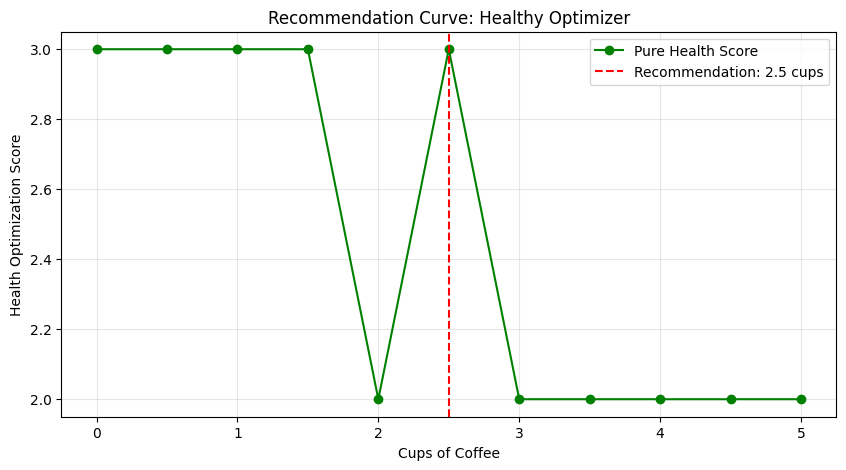

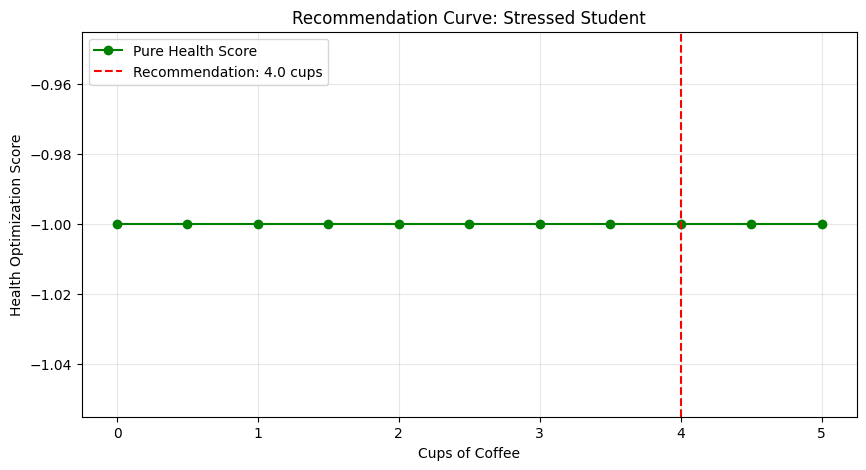

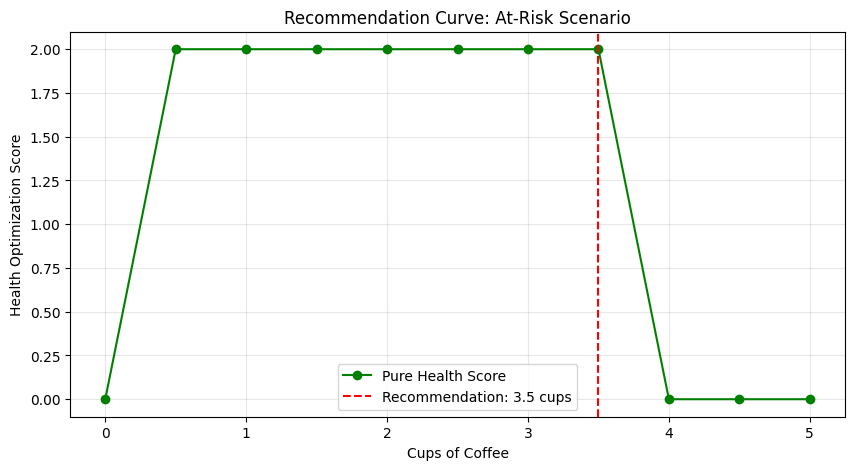

In [53]:
plot_recommendation_curve(pd.Series(user_healthy), "Healthy Optimizer")
plot_recommendation_curve(pd.Series(user_stressed), "Stressed Student")
plot_recommendation_curve(pd.Series(user_at_risk), "At-Risk Scenario")